# Decision Tree (DT) for regression problems. 
In this lab we train a DT with synthetic data for a regression problem (prediction of a real number). In this example, we simulate the prediction of the average packet size of a flow given the duration of that flow.

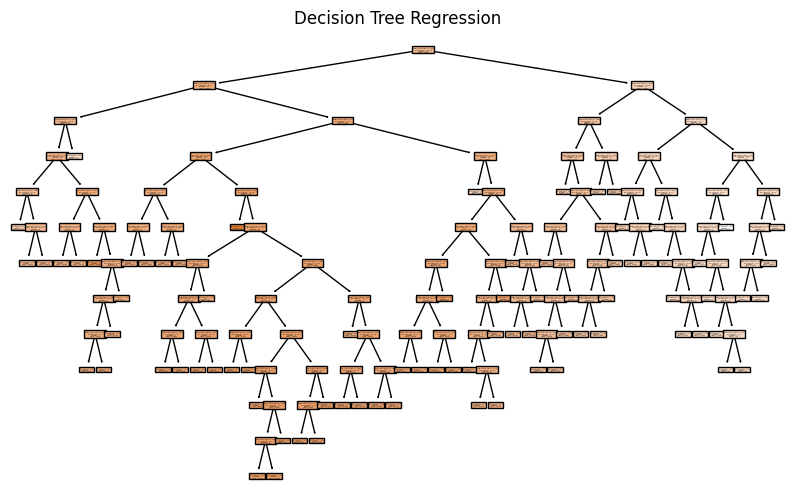

In [3]:
# Author: Roberto Doriguzzi-Corin
# Project: Course on Network Intrusion and Anomaly Detection with Deep Learning
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Import necessary libraries
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

OUTPUT_FILE = "./reg_tree"

# Generate some sample data (a sin function with some random noise)
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = 80 + 5*np.sin(X).ravel()
y[::5] += 10 * (np.random.rand(16))
y[::5] += -10 * (np.random.rand(16))

# Fit a decision tree regressor
tree_regr = DecisionTreeRegressor(max_depth=3) # try with min_samples_leaf to avoid overfitting
tree_regr.fit(X, y)

# Plot the decision tree
plt.figure(figsize=(10, 6))
plot_tree(tree_regr, filled=True, feature_names=["Flow duration (sec)"])
plt.title("Decision Tree Regression")
plt.show()

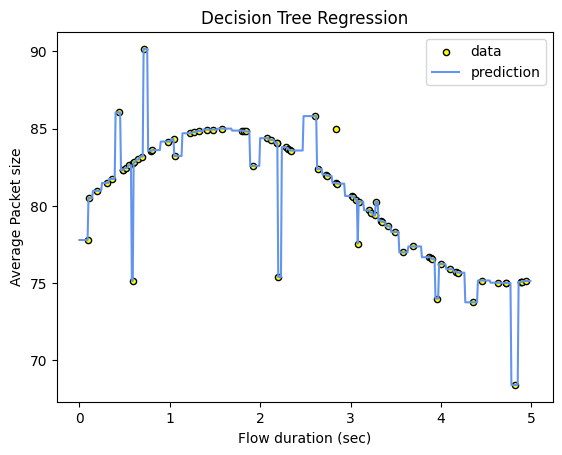

In [4]:
# Predictions (numbers from 0 to 5 with increment 0.01)
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred = tree_regr.predict(X_test)

# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="yellow", label="data")
plt.plot(X_test, y_pred, color="cornflowerblue", label="prediction")
plt.xlabel("Flow duration (sec)")
plt.ylabel("Average Packet size")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()